In [2]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
import h5py
from IPython.display import clear_output
import random
from scipy.io import loadmat
from scipy.stats import spearmanrho
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from useful_stuff.general_utils.utils import TimeSeries, compatible_TimeSeries_check, print_wise, get_lagplot, get_centroid
from useful_stuff.image_processing.computational_models import get_relevant_output_layers
from project_specific_utils.dataloader import load_concat_regressout_meg
from analyses.subsampling_lagged_comparisons import save_lagged_comparisons


In [3]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    sub_num = 8
    neu_fs = 100
    gaze_fs = 50
    sq_side = 384
    sensors_group = 'occ'
    model_name = "dino_v3_l"
    pkg = "hf"
    len_or_lag = 600
    pseudotrials_n = 100
    n_model_components = 1000
    pooling = "all"
    PCs_to_regress_out = 50
    iterations_n = 1000
    repetition = 0
    signal_metric = "cosine_cnt"
    model_metric = "cosine_cnt"
    regress_out_gaze = 'PCR' # or None or pointwise
    PCs_to_regress_out = 50
    max_lag = 200
    analysis_type = "RSA"
    tick_step = 100
    min_peak_percent = .2
    negative_lim = .8
    min_fit_cutoff = .002
cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, pkg=cfg.pkg)
mod_fs = config["movie_fs"]
model_len = [round(i*cfg.neu_fs/config["movie_fs"]) for i in config["model_len"]]

# SUBJECTS AVERAGE

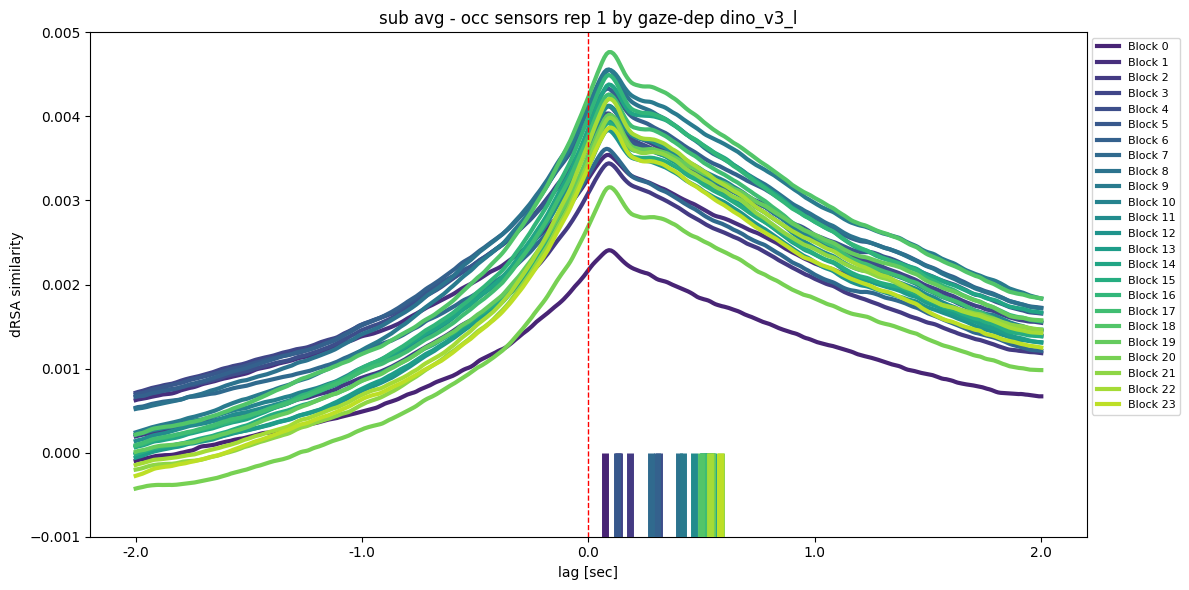

In [20]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from useful_stuff.general_utils.plots import truncate_colormap
from useful_stuff.general_utils.utils import get_lagplot
from useful_stuff.image_processing.computational_models import get_relevant_output_layers

lagplots = []
# --- choose colormap ---
cmap = truncate_colormap(plt.cm.viridis)  # or "plasma", "coolwarm", etc.
colors = cmap(np.linspace(0, 1, len(layers)))
peaks = []
centroids = []
ticks = np.arange(-cfg.max_lag, cfg.max_lag + 1, cfg.tick_step)
ticks_labels = np.round(ticks / cfg.neu_fs, 2)
ticks += cfg.max_lag
plt.figure(figsize=(12, 6))
all_peaks = []
all_centroids = []
avg_centroids = []
lags = np.arange(-cfg.max_lag, cfg.max_lag + 1)
for idx, l in enumerate(layers):
        full_model_name = f"{cfg.model_name}_{l}"
        sub_counter = 0
        # lagplot_sum = np.zeros(cfg.max_lag*2 +1, cfg.max_lag*2 +1)
        lagplot_sum = np.zeros((cfg.len_or_lag, cfg.len_or_lag))
        for i_sub in config["subjects"][:10]:
            try:
                res_path = save_lagged_comparisons(paths, cfg.analysis_type, i_sub, cfg.sensors_group, cfg.repetition, full_model_name, cfg.iterations_n, cfg.len_or_lag, cfg.neu_fs, signal_metric=cfg.signal_metric, model_metric=cfg.model_metric, pseudotrials_n=cfg.pseudotrials_n, sq_side=cfg.sq_side, regress_out_gaze=cfg.regress_out_gaze)
                res = loadmat(res_path)["RSA"]    
                lagplot = get_lagplot(res, cfg.max_lag)
                sub_counter +=1
            except FileNotFoundError:
                print_wise(f"sub={i_sub} layer={l} not found")
                continue
            peak_lag = (np.argmax(lagplot) - cfg.max_lag) / cfg.neu_fs  # convert to seconds
            all_peaks.append([idx, peak_lag])
            weights = lagplot.copy()
            weights[weights < 0] = 0  # optional but recommended
            if not np.all(weights==0):
                centroid = np.sum(lags * weights) / np.sum(weights)
                centroid_lag = np.round(centroid / cfg.neu_fs, 5)
                all_centroids.append([idx, centroid_lag])
            lagplot_sum += res
        avg_lagplot = lagplot_sum/sub_counter
        avg_lagplot = get_lagplot(avg_lagplot, max_lag=cfg.max_lag)
        lagplots.append(avg_lagplot)
        # --- compute peak ---
        peak_idx = np.argmax(avg_lagplot)
        
        centroid_lag = get_centroid(avg_lagplot, cfg.max_lag, cfg.neu_fs)
        if np.max(lagplot)>cfg.min_fit_cutoff:
            if np.sum(lagplot < 0) < cfg.negative_lim*len(lagplot):
                centroid_lag = get_centroid(lagplot, cfg.max_lag, cfg.neu_fs, min_peak_percent=cfg.min_peak_percent)
            else:
                centroid_lag = np.nan
        else: 
            centroid_lag = np.nan
        if not np.isnan(centroid_lag):
            peak_val = avg_lagplot[peak_idx]
            peak_lag = (peak_idx - cfg.max_lag) / cfg.neu_fs  # convert to seconds
            peaks.append(peak_lag)
            centroids.append(centroid_lag)
        
        plt.plot(avg_lagplot, linewidth=3, label=f"Block {idx}", color=colors[idx])
        avg_centroids.append(get_centroid(avg_lagplot, cfg.max_lag, cfg.neu_fs, min_peak_percent=cfg.min_peak_percent))
        if not np.isnan(centroid_lag):
            centroid_idx = centroid_lag * cfg.neu_fs + cfg.max_lag
            centroid_y = np.interp(centroid_idx, np.arange(len(avg_lagplot)), avg_lagplot)
            # plt.scatter(
            # centroid_idx,
            # centroid_y,
            # marker="x",
            # s=80,
            # linewidths=2,
            # color=colors[idx],
            # zorder=5,
            # )
            plt.vlines(
                centroid_idx,
                -.001,
                -.001 + 0.001,
                color=colors[idx],
                linewidth=5,  # increased line width
                zorder=15,
            )
        plt.ylim([-.001,.005])
plt.ylabel("dRSA similarity")
plt.xlabel("lag [sec]")
plt.xticks(ticks, ticks_labels)
plt.axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)
        

plt.title(f"sub avg - {cfg.sensors_group} sensors rep {cfg.repetition+1} by gaze-dep {cfg.model_name}")#{cfg.sensors_group} sensors - regr out")
plt.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

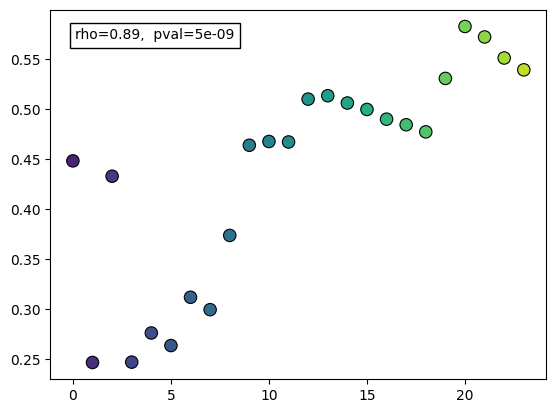

In [18]:
rho = spearmanrho(np.arange(len(avg_centroids)), avg_centroids)
r = np.corrcoef(np.arange(len(avg_centroids)), avg_centroids)[0,1]
fig, ax = plt.subplots(1)
ax.scatter(np.arange(len(avg_centroids)), avg_centroids, c=colors[:len(avg_centroids)], s=80, edgecolors='k', linewidths=0.8)
ax.text(
    0.05, 0.95,              # slightly inside the corner
    f"rho={round(rho.statistic, 2)},  pval={rho.pvalue:.0e}",
    transform=ax.transAxes,
    ha='left',               # horizontal alignment
    va='top',                # vertical alignment
    bbox=dict(facecolor='white', edgecolor='black')
);

In [137]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from useful_stuff.general_utils.plots import truncate_colormap
from useful_stuff.general_utils.utils import get_lagplot
from useful_stuff.image_processing.computational_models import get_relevant_output_layers

lagplots = []
# --- choose colormap ---
cmap = truncate_colormap(plt.cm.viridis)  # or "plasma", "coolwarm", etc.
colors = cmap(np.linspace(0, 1, len(layers)))
peaks = []
ticks = np.arange(-cfg.max_lag, cfg.max_lag + 1, cfg.tick_step)
ticks_labels = np.round(ticks / cfg.neu_fs, 2)
ticks += cfg.max_lag
all_peaks = []
all_centroids = []
lags = np.arange(-cfg.max_lag, cfg.max_lag + 1)
rhos = []
model_fit = []
for i_sub in config["subjects"][:10]:
    avg_lagplot = np.zeros(cfg.max_lag*2 +1)
    layers_counter = 0
    layers_idx = []
    centroids = []
    for idx, l in enumerate(layers):
        full_model_name = f"{cfg.model_name}_{l}"
        try:
            res_path = save_lagged_comparisons(paths, cfg.analysis_type, i_sub, cfg.sensors_group, cfg.repetition, full_model_name, cfg.iterations_n, cfg.len_or_lag, cfg.neu_fs, signal_metric=cfg.signal_metric, model_metric=cfg.model_metric, pseudotrials_n=cfg.pseudotrials_n, sq_side=cfg.sq_side, regress_out_gaze=cfg.regress_out_gaze)
            res = loadmat(res_path)["RSA"]    
            lagplot = get_lagplot(res, cfg.max_lag)
            avg_lagplot+=lagplot
            layers_counter +=1
        except FileNotFoundError:
            print_wise(f"sub={i_sub} layer={l} not found")
            continue
        if np.max(lagplot)>0:
            if np.sum(lagplot < 0) < cfg.negative_lim*len(lagplot):
                centroid_lag = get_centroid(lagplot, cfg.max_lag, cfg.neu_fs, min_peak_percent=cfg.min_peak_percent)
            else:
                centroid_lag = np.nan
        else: 
            centroid_lag = np.nan
        if not np.isnan(centroid_lag):
            centroids.append(centroid_lag)
            layers_idx.append(idx)
    if len(centroids)>3:
        rhos.append(spearmanrho(centroids, layers_idx).statistic)
        subject_fit = np.max(avg_lagplot/layers_counter)
        model_fit.append(subject_fit)
        

In [ ]:
np.round(rhos, 3)

array([ 0.675,  0.903,  0.064,  0.935,  0.589,  0.494, -0.165,  0.367,
       -0.17 ,  0.899])

In [155]:
np.round(model_fit, 5)

array([0.00416, 0.00512, 0.00329, 0.00385, 0.00373, 0.00525, 0.00186,
       0.00367, 0.00137, 0.00786])

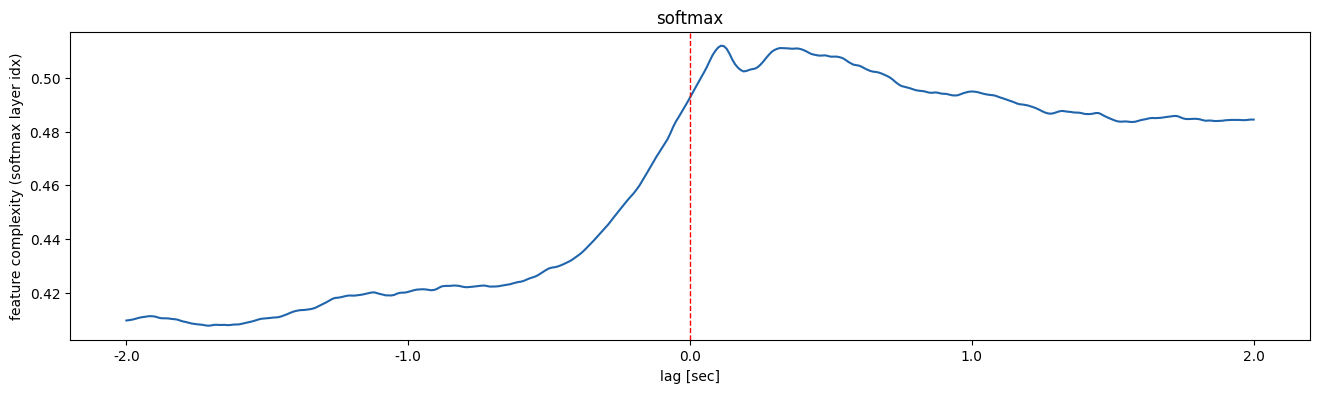

In [25]:
from useful_stuff.general_utils.utils import softmax
lps = np.stack(lagplots, axis=0)
softmax_lp = []
hardmax_lp = []


temp_range = np.arange(0.001, 1, 0.1)
cmap = truncate_colormap(plt.cm.RdBu)
colors = cmap(np.linspace(0, 1, len(temp_range)))[::-1]
fig, ax = plt.subplots(1,figsize=(16,4))

for idx, temp in enumerate(temp_range[:1]):
    softmax_lp = []
    for t in range(lps.shape[1]):
        softmax_lp.append(softmax(lps[:,t], T=temp)@np.arange(lps.shape[0])/lps.shape[0])
        if temp==temp_range[-1]:
            hardmax_lp.append(np.argmax(lps[:,t]))
    # plt.plot(softmax_lp, label=f"peak={(np.argmax(softmax_lp)-cfg.max_lag)/cfg.neu_fs}ms", color=colors[idx])
    ax.plot(softmax_lp, label=f"peak={(np.argmax(softmax_lp)-cfg.max_lag)/cfg.neu_fs}ms", color=colors[idx])
    ax.axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)
    ax.set_xticks(ticks, ticks_labels)
    ax.set_xlabel("lag [sec]")
    ax.set_ylabel("feature complexity (softmax layer idx)")
    ax.set_title("softmax")
